In [1]:
import json
import math
import re
import unicodedata
import urllib.request
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

SAVE_FIGURES = False
MAP_OUTPUT_DIR = Path("outputs/maps")

REGIONS_GEOJSON_URL = "https://raw.githubusercontent.com/openpolis/geojson-italy/master/geojson/limits_IT_regions.geojson"
PROVINCES_GEOJSON_URL = "https://raw.githubusercontent.com/openpolis/geojson-italy/master/geojson/limits_IT_provinces.geojson"

outlets = pd.read_csv("Data/QSR_outlet_dataset_cleaned.csv", keep_default_na=False)
socioeconomic = pd.read_csv("Data/QSR_socioeconomic_dataset_cleaned.csv")

regional_qsr = outlets.groupby("Region").agg(
    Outlet_Count=("Outlet ID", "count"),
    Average_Rating=("Customer_Rating", "mean"),
    Average_Review_Count=("Review_Count", "mean")
).reset_index()

regional_analysis = regional_qsr.merge(
    socioeconomic,
    on="Region",
    how="left"
)

regional_analysis["Outlets_per_100k_people"] = (
    regional_analysis["Outlet_Count"] / regional_analysis["Population"] * 100000
)

def load_geojson(url):
    with urllib.request.urlopen(url, timeout=60) as response:
        return json.load(response)

regions_geojson = load_geojson(REGIONS_GEOJSON_URL)
provinces_geojson = load_geojson(PROVINCES_GEOJSON_URL)

def standard_region_name(name):
    name = str(name).strip().replace("’", "'")
    if "/" in name:
        name = name.split("/")[0].strip()
    return name

def normalize_key(value):
    value = standard_region_name(value)
    value = unicodedata.normalize("NFKD", value)
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    value = value.lower()
    value = re.sub(r"[^a-z0-9]+", "", value)
    return value

def geometry_to_rings(geometry):
    if geometry["type"] == "Polygon":
        return [geometry["coordinates"][0]]
    if geometry["type"] == "MultiPolygon":
        return [polygon[0] for polygon in geometry["coordinates"]]
    raise ValueError(f"Unsupported geometry type: {geometry['type']}")

def build_region_records(geojson_data):
    records = []
    for feature in geojson_data["features"]:
        region_name = standard_region_name(feature["properties"]["reg_name"])
        records.append({
            "name": region_name,
            "key": normalize_key(region_name),
            "rings": geometry_to_rings(feature["geometry"]),
        })
    return records

def build_province_records(geojson_data):
    records = []
    for feature in geojson_data["features"]:
        province_code = str(feature["properties"]["prov_acr"]).strip()
        province_name = str(feature["properties"]["prov_name"]).strip()
        records.append({
            "name": province_name,
            "key": province_code,
            "rings": geometry_to_rings(feature["geometry"]),
        })
    return records

region_records = build_region_records(regions_geojson)
province_records = build_province_records(provinces_geojson)

def save_figure(fig, filename):
    if SAVE_FIGURES:
        MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(MAP_OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")

def plot_choropleth(records, values_by_key, title, colorbar_label, filename=None, cmap="YlOrRd", figsize=(9, 10)):
    polygons = []
    polygon_values = []
    missing_keys = []

    for record in records:
        value = values_by_key.get(record["key"])
        if value is None:
            missing_keys.append(record["key"])
        for ring in record["rings"]:
            polygons.append([(lon, lat) for lon, lat in ring])
            polygon_values.append(value)

    valid_values = [v for v in polygon_values if pd.notna(v)]
    if not valid_values:
        raise ValueError("No valid values were found for this choropleth map.")

    norm = Normalize(vmin=min(valid_values), vmax=max(valid_values))
    color_map = plt.get_cmap(cmap)
    facecolors = ["#eeeeee" if pd.isna(v) else color_map(norm(v)) for v in polygon_values]

    fig, ax = plt.subplots(figsize=figsize)
    collection = PolyCollection(
        polygons,
        facecolors=facecolors,
        edgecolors="white",
        linewidths=0.45
    )
    ax.add_collection(collection)
    ax.autoscale()
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=16, pad=16)

    colorbar = fig.colorbar(ScalarMappable(norm=norm, cmap=color_map), ax=ax, shrink=0.65, pad=0.02)
    colorbar.set_label(colorbar_label)

    if missing_keys:
        print("Map keys without data:", sorted(set(missing_keys)))

    if filename:
        save_figure(fig, filename)

    plt.show()
    return fig, ax

def draw_region_base(ax, facecolor="#f7f7f7", edgecolor="#cccccc", linewidth=0.5):
    polygons = []
    for record in region_records:
        for ring in record["rings"]:
            polygons.append([(lon, lat) for lon, lat in ring])
    collection = PolyCollection(
        polygons,
        facecolors=facecolor,
        edgecolors=edgecolor,
        linewidths=linewidth
    )
    ax.add_collection(collection)
    ax.autoscale()
    ax.set_aspect("equal")
    ax.axis("off")

def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    d_phi = math.radians(lat2 - lat1)
    d_lambda = math.radians(lon2 - lon1)
    a = math.sin(d_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(d_lambda / 2) ** 2
    return 2 * radius_km * math.asin(math.sqrt(a))

region_keys_from_map = {record["key"] for record in region_records}
region_keys_from_data = {normalize_key(region) for region in regional_analysis["Region"]}
print("Outlet rows:", len(outlets))
print("Regions in analysis table:", len(regional_analysis))
print("Region map keys without data:", sorted(region_keys_from_map - region_keys_from_data))
print("Data region keys without map geometry:", sorted(region_keys_from_data - region_keys_from_map))

Outlet rows: 2816
Regions in analysis table: 20
Region map keys without data: []
Data region keys without map geometry: []


## Map 1: Total QSR Outlets by Region

This choropleth map shows the absolute number of QSR outlets in each Italian region. Darker regions have more outlets in total.

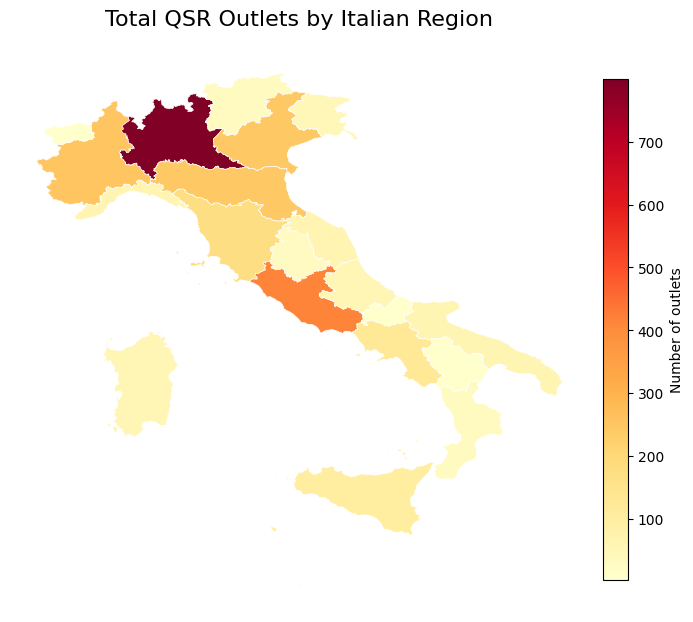

In [2]:
region_outlet_counts = {
    normalize_key(row["Region"]): row["Outlet_Count"]
    for _, row in regional_analysis.iterrows()
}

plot_choropleth(
    region_records,
    region_outlet_counts,
    title="Total QSR Outlets by Italian Region",
    colorbar_label="Number of outlets",
    filename="outlets_by_region.png",
    cmap="YlOrRd"
);

## Map 2: QSR Outlets per 100,000 People by Region

This map normalizes outlet counts by population. It is useful because raw outlet counts can be misleading when regions have very different population sizes.

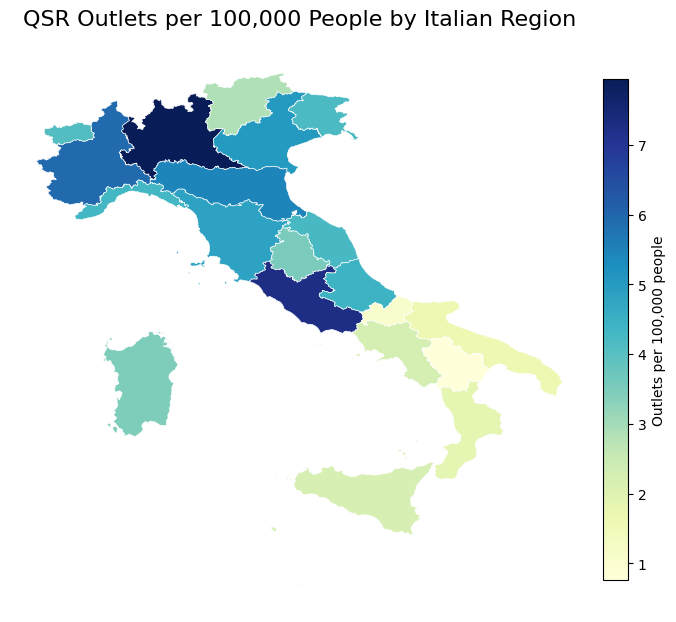

In [3]:
region_outlets_per_100k = {
    normalize_key(row["Region"]): row["Outlets_per_100k_people"]
    for _, row in regional_analysis.iterrows()
}

plot_choropleth(
    region_records,
    region_outlets_per_100k,
    title="QSR Outlets per 100,000 People by Italian Region",
    colorbar_label="Outlets per 100,000 people",
    filename="outlets_per_100k_by_region.png",
    cmap="YlGnBu"
);

## Map 3: Total QSR Outlets by Province

This map shows raw outlet counts by province.

Province codes in data without map geometry: ['OT']
Province map codes without QSR outlets: []


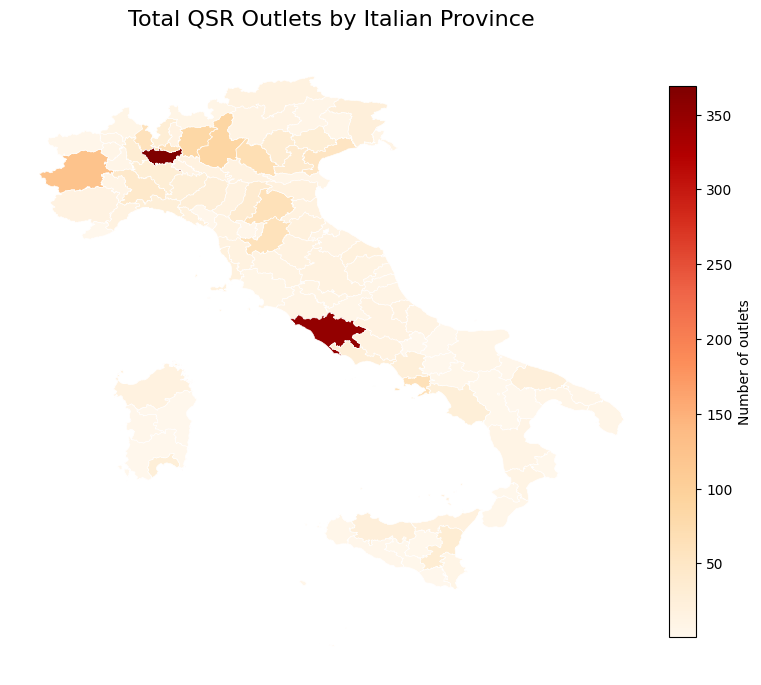

In [4]:
province_outlet_counts = outlets.groupby("Province_Shorthand").size().to_dict()
province_codes_from_map = {record["key"] for record in province_records}
province_codes_from_data = set(province_outlet_counts)

print("Province codes in data without map geometry:", sorted(province_codes_from_data - province_codes_from_map))
print("Province map codes without QSR outlets:", sorted(province_codes_from_map - province_codes_from_data))

plot_choropleth(
    province_records,
    province_outlet_counts,
    title="Total QSR Outlets by Italian Province",
    colorbar_label="Number of outlets",
    filename="outlets_by_province.png",
    cmap="OrRd",
    figsize=(10, 11)
);

## Map 4: Outlet Concentration Around Main Cities

This map aggregates outlets by city and plots the top 20 cities. Larger circles indicate more QSR outlets. This helps show whether QSR outlets are concentrated around major urban areas.

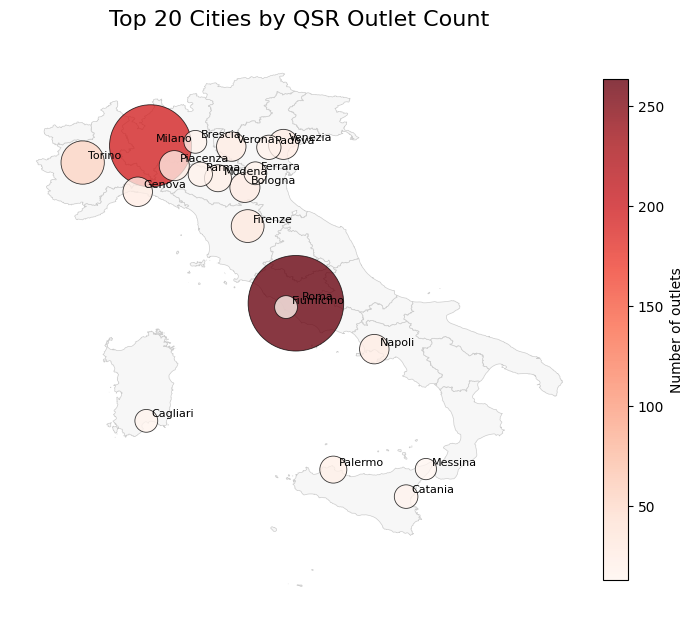

,City,Region,Outlet_Count
623,Roma,Lazio,263
467,Milano,Lombardia,194
741,Torino,Piemonte,54
306,Firenze,Toscana,31
89,Bologna,Emilia-Romagna,26
778,Venezia,Veneto,26
558,Piacenza,Emilia-Romagna,26
501,Napoli,Campania,25
786,Verona,Veneto,25
340,Genova,Liguria,25


In [5]:
city_summary = outlets.groupby(["City", "Region"]).agg(
    Outlet_Count=("Outlet ID", "count"),
    Latitude=("Latitude", "mean"),
    Longitude=("Longitude", "mean")
).reset_index()

top_cities = city_summary.sort_values("Outlet_Count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 10))
draw_region_base(ax)

sizes = top_cities["Outlet_Count"] * 18
scatter = ax.scatter(
    top_cities["Longitude"],
    top_cities["Latitude"],
    s=sizes,
    c=top_cities["Outlet_Count"],
    cmap="Reds",
    edgecolors="black",
    linewidths=0.6,
    alpha=0.78
)

for _, row in top_cities.iterrows():
    ax.annotate(
        row["City"],
        (row["Longitude"], row["Latitude"]),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Top 20 Cities by QSR Outlet Count", fontsize=16, pad=16)
colorbar = fig.colorbar(scatter, ax=ax, shrink=0.65, pad=0.02)
colorbar.set_label("Number of outlets")
save_figure(fig, "top_cities_qsr_concentration.png")
plt.show()

top_cities[["City", "Region", "Outlet_Count"]]

## Map 5: Exploratory City Connection Map

This is not a formal network model. It is a simple exploratory visualization that connects each of the top 20 cities to its nearest major QSR city. The purpose is to visually suggest possible spatial corridors of QSR concentration around large cities and transport routes.

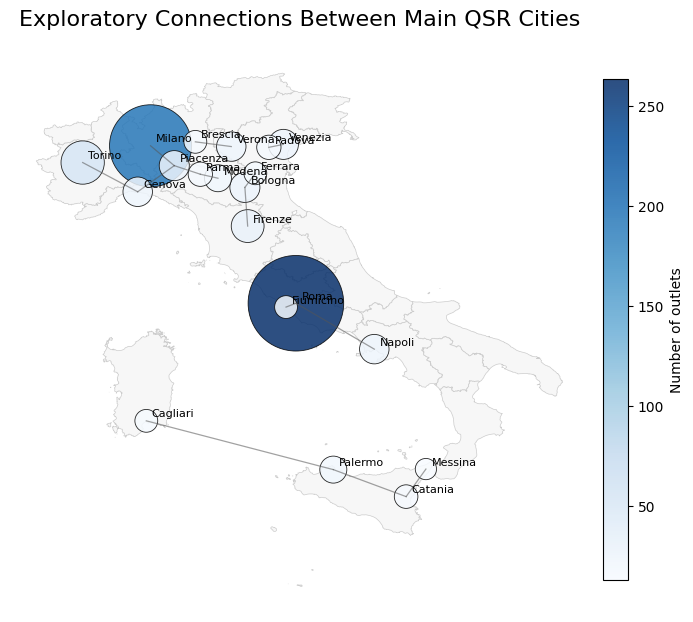

,City_1,City_2,Distance_km
1,Roma,Fiumicino,20.8
6,Venezia,Padova,26.7
12,Modena,Parma,33.1
5,Bologna,Ferrara,40.1
8,Piacenza,Parma,51.1
9,Verona,Brescia,64.4
2,Milano,Piacenza,65.2
13,Catania,Messina,79.6
7,Piacenza,Genova,92.6
4,Firenze,Bologna,97.3


In [6]:
network_cities = top_cities.reset_index(drop=True).copy()
edges = set()

for i, city in network_cities.iterrows():
    distances = []
    for j, other_city in network_cities.iterrows():
        if i == j:
            continue
        distance = haversine_km(
            city["Latitude"], city["Longitude"],
            other_city["Latitude"], other_city["Longitude"]
        )
        distances.append((distance, i, j))
    nearest_distance, source_index, target_index = sorted(distances)[0]
    edges.add(tuple(sorted((source_index, target_index))))

fig, ax = plt.subplots(figsize=(9, 10))
draw_region_base(ax)

for source_index, target_index in edges:
    source = network_cities.loc[source_index]
    target = network_cities.loc[target_index]
    ax.plot(
        [source["Longitude"], target["Longitude"]],
        [source["Latitude"], target["Latitude"]],
        color="#555555",
        linewidth=0.9,
        alpha=0.55
    )

scatter = ax.scatter(
    network_cities["Longitude"],
    network_cities["Latitude"],
    s=network_cities["Outlet_Count"] * 18,
    c=network_cities["Outlet_Count"],
    cmap="Blues",
    edgecolors="black",
    linewidths=0.6,
    alpha=0.85
)

for _, row in network_cities.iterrows():
    ax.annotate(
        row["City"],
        (row["Longitude"], row["Latitude"]),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Exploratory Connections Between Main QSR Cities", fontsize=16, pad=16)
colorbar = fig.colorbar(scatter, ax=ax, shrink=0.65, pad=0.02)
colorbar.set_label("Number of outlets")
save_figure(fig, "top_cities_qsr_network.png")
plt.show()

network_edges = []
for source_index, target_index in sorted(edges):
    source = network_cities.loc[source_index]
    target = network_cities.loc[target_index]
    network_edges.append({
        "City_1": source["City"],
        "City_2": target["City"],
        "Distance_km": round(haversine_km(source["Latitude"], source["Longitude"], target["Latitude"], target["Longitude"]), 1)
    })

pd.DataFrame(network_edges).sort_values("Distance_km")